# currency-rounder - the cent a ledger loses, and where it goes

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/currency-rounder/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/currency-rounder/demo.ipynb)

**Day 143 - Data Engineering Pro - [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)**

A rounding function returns a number. It cannot return the fact that the rows no longer add up.

Round every line of a ledger correctly, to the nearest cent, using the mode your language
gives you by default, and the ledger can still be a cent short of its own total. No row is
wrong. Nothing raises. The report reconciles against itself on a re-run, because the error
is perfectly reproducible.

This notebook walks through eight mechanisms that produce a wrong money figure silently:

1. Independent rounding does not preserve a sum
2. Sorting the ledger moves the cent onto a different row
3. `half_even` is the language default; `half_up` is what most tax codes say
4. The float you rounded is not the number you typed
5. Rounding does not commute - line tax vs invoice tax, discount before vs after
6. Two decimal places is an assumption, and ISO 4217 does not share it
7. The books and the till settle at different totals, and both are correct
8. The ledger: what each failure costs, and whether anything raises

Then it builds a **three-verdict** audit - `exact`, `reconciled`, `irreconcilable` - and a
six-panel figure. Everything below runs on the standard library plus matplotlib.

## Step 0 - write the modules

The notebook carries the real source of `money.py`, `evidence.py` and `make_chart.py`
inline and writes them to disk. That keeps it self-contained on Colab and keeps the
notebook honest: it runs the same code the repo ships, not a simplified retelling.

In [1]:
import base64, pathlib
_money_b64 = (
    "..."
)
_src = base64.b64decode(_money_b64).decode()
pathlib.Path("money.py").write_text(_src)
print("wrote money.py:", len(_src.splitlines()), "lines")

wrote money.py: 633 lines


In [2]:
import base64, pathlib
_evidence_b64 = (
    "..."
)
_src = base64.b64decode(_evidence_b64).decode()
pathlib.Path("evidence.py").write_text(_src)
print("wrote evidence.py:", len(_src.splitlines()), "lines")

wrote evidence.py: 318 lines


In [3]:
import base64, pathlib
_make_chart_b64 = (
    "IiIiU2l4LXBhbmVsIGF1ZGl0IGZpZ3VyZSBmb3IgY3VycmVuY3ktcm91bmRlci4KCkV2ZXJ5IG51bWJlciBwbG90"
    "dGVkIGlzIGNvbXB1dGVkIGhlcmUgZnJvbSBtb25leS5weSwgbm90IHR5cGVkIGluLgoKUnVuOiBweXRob24zIG1h"
    "a2VfY2hhcnQucHkgW291dGZpbGUucG5nXSBbLS1kcGkgTl0KIiIiCgpmcm9tIF9fZnV0dXJlX18gaW1wb3J0IGFu"
    "bm90YXRpb25zCgppbXBvcnQgcmFuZG9tCmltcG9ydCBzeXMKZnJvbSBkZWNpbWFsIGltcG9ydCBEZWNpbWFsIGFz"
    "IEQKCgppbXBvcnQgbWF0cGxvdGxpYgoKbWF0cGxvdGxpYi51c2UoIkFnZyIpCmltcG9ydCBtYXRwbG90bGliLnB5"
    "cGxvdCBhcyBwbHQKaW1wb3J0IG51bXB5IGFzIG5wCgppbXBvcnQgbW9uZXkgYXMgbQoKSU5LID0gIiMxYjFiMWYi"
    "Ck1VVEVEID0gIiM3YTdhODUiCkdSSUQgPSAiI2U2ZTZlYyIKQkFEID0gIiNjMjM4NGEiCk9LID0gIiMyZjdkNWMi"
    "CldBUk4gPSAiI2Q5ODMyNCIKQ09PTCA9ICIjMmY1ZDllIgpGSUxMID0gIiNmNGY0ZjciCgoKZGVmIF9zdHlsZShh"
    "eCwgdGl0bGU6IHN0ciwgc3ViOiBzdHIgPSAiIikgLT4gTm9uZToKICAgIGF4LnNldF90aXRsZSh0aXRsZSwgZm9u"
    "dHNpemU9MTEuNSwgZm9udHdlaWdodD0iYm9sZCIsIGNvbG9yPUlOSywgbG9jPSJsZWZ0IiwgcGFkPTMwKQogICAg"
    "aWYgc3ViOgogICAgICAgIGF4LnRleHQoCiAgICAgICAgICAgIDAsIDEuMDE4LCBzdWIsIHRyYW5zZm9ybT1heC50"
    "cmFuc0F4ZXMsIGZvbnRzaXplPTguNCwgY29sb3I9TVVURUQsIHZhPSJib3R0b20iLCBoYT0ibGVmdCIKICAgICAg"
    "ICApCiAgICBmb3IgcyBpbiAoInRvcCIsICJyaWdodCIpOgogICAgICAgIGF4LnNwaW5lc1tzXS5zZXRfdmlzaWJs"
    "ZShGYWxzZSkKICAgIGZvciBzIGluICgibGVmdCIsICJib3R0b20iKToKICAgICAgICBheC5zcGluZXNbc10uc2V0"
    "X2NvbG9yKEdSSUQpCiAgICBheC50aWNrX3BhcmFtcyhjb2xvcnM9TVVURUQsIGxhYmVsc2l6ZT04LjIsIGxlbmd0"
    "aD0zKQogICAgYXguZ3JpZChheGlzPSJ5IiwgY29sb3I9R1JJRCwgbHc9MC44LCB6b3JkZXI9MCkKICAgIGF4LnNl"
    "dF9heGlzYmVsb3coVHJ1ZSkKCgojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0t"
    "LS0tLS0tLS0tLS0tLS0tLS0tLSBwYW5lbCAxCgoKZGVmIHAxX3Nob3J0ZmFsbChheCkgLT4gTm9uZToKICAgICIi"
    "IkhvdyBmYXIgb2ZmIGEgbGVkZ2VyIGxhbmRzIHdoZW4gZXZlcnkgcm93IGlzIHJvdW5kZWQgb24gaXRzIG93bi4i"
    "IiIKICAgIHVzZCA9IG0uY3VycmVuY3koIlVTRCIpCiAgICBucyA9IGxpc3QocmFuZ2UoMiwgNDEpKQogICAgd29y"
    "c3QsIG1lYW4gPSBbXSwgW10KICAgIGZvciBuIGluIG5zOgogICAgICAgIGdhcHMgPSBbXQogICAgICAgIGZvciB0"
    "b3RhbF9jZW50cyBpbiByYW5nZSgxMDAsIDEwMCArIDYwKToKICAgICAgICAgICAgdG90YWwgPSBEKHRvdGFsX2Nl"
    "bnRzKSAvIDEwMAogICAgICAgICAgICBleGFjdCA9IEQodG90YWwpIC8gbgogICAgICAgICAgICBuYWl2ZSA9IG0u"
    "cXVhbnRpemUoZXhhY3QsIHVzZCwgImhhbGZfZXZlbiIpICogbgogICAgICAgICAgICBnYXBzLmFwcGVuZChmbG9h"
    "dChuYWl2ZSAtIHRvdGFsKSkKICAgICAgICB3b3JzdC5hcHBlbmQobWF4KGFicyhnKSBmb3IgZyBpbiBnYXBzKSAq"
    "IDEwMCkKICAgICAgICBtZWFuLmFwcGVuZChmbG9hdChucC5tZWFuKFthYnMoZykgZm9yIGcgaW4gZ2Fwc10pKSAq"
    "IDEwMCkKCiAgICBheC5wbG90KG5zLCB3b3JzdCwgY29sb3I9QkFELCBsdz0yLjAsIHpvcmRlcj0zLCBsYWJlbD0i"
    "d29yc3QgY2FzZSIpCiAgICBheC5wbG90KG5zLCBtZWFuLCBjb2xvcj1DT09MLCBsdz0xLjgsIGxzPSItLSIsIHpv"
    "cmRlcj0zLCBsYWJlbD0ibWVhbiIpCiAgICBheC5maWxsX2JldHdlZW4obnMsIDAsIHdvcnN0LCBjb2xvcj1CQUQs"
    "IGFscGhhPTAuMDcsIHpvcmRlcj0xKQogICAgYXguYXhobGluZSgwLCBjb2xvcj1HUklELCBsdz0xKQogICAgYXgu"
    "c2V0X3hsYWJlbCgicm93cyB0aGUgdG90YWwgaXMgc3BsaXQgYWNyb3NzIiwgZm9udHNpemU9OC40LCBjb2xvcj1N"
    "VVRFRCkKICAgIGF4LnNldF95bGFiZWwoImxlZGdlciBlcnJvciAoY2VudHMpIiwgZm9udHNpemU9OC40LCBjb2xv"
    "cj1NVVRFRCkKICAgIGF4LmxlZ2VuZChmcmFtZW9uPUZhbHNlLCBmb250c2l6ZT04LCBsb2M9InVwcGVyIGxlZnQi"
    "KQogICAgcGVhayA9IG1heCh3b3JzdCkKICAgIGF4LmFubm90YXRlKAogICAgICAgIGYidXAgdG8ge3BlYWs6LjBm"
    "fWMgYWRyaWZ0XG5vbiBhIHNpbmdsZSBsZWRnZXIiLAogICAgICAgIHh5PShuc1t3b3JzdC5pbmRleChwZWFrKV0s"
    "IHBlYWspLAogICAgICAgIHh5dGV4dD0oMjQsIHBlYWsgKiAwLjU1KSwKICAgICAgICBmb250c2l6ZT04LjIsCiAg"
    "ICAgICAgY29sb3I9QkFELAogICAgICAgIGFycm93cHJvcHM9ZGljdChhcnJvd3N0eWxlPSItPiIsIGNvbG9yPUJB"
    "RCwgbHc9MSksCiAgICApCiAgICBfc3R5bGUoCiAgICAgICAgYXgsCiAgICAgICAgIjEuIEluZGVwZW5kZW50IHJv"
    "dW5kaW5nIGRvZXMgbm90IHByZXNlcnZlIGEgc3VtIiwKICAgICAgICAiZWFjaCByb3cgY29ycmVjdGx5IHJvdW5k"
    "ZWQgdG8gdGhlIG5lYXJlc3QgY2VudDsgbGVkZ2VyIHZzIHN0YXRlZCB0b3RhbCwgNjAgdG90YWxzIHBlciBuIiwK"
    "ICAgICkKCgojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0t"
    "LS0tLS0tLSBwYW5lbCAyCgoKZGVmIHAyX3dob19wYXlzKGF4KSAtPiBOb25lOgogICAgIiIiU2FtZSB0b3RhbCwg"
    "c2FtZSBzaGFyZXMsIGRpZmZlcmVudCByb3cgb3JkZXI6IHRoZSBwZW5ueSBtb3Zlcy4iIiIKICAgIHVzZCA9IG0u"
    "Y3VycmVuY3koIlVTRCIpCiAgICBuYW1lcyA9IFsiYWxpY2UiLCAiYm9iIiwgImNhcm9sIl0KICAgIG9yZGVycyA9"
    "IFsKICAgICAgICAoImNhcm9sLCBhbGljZSwgYm9iIiwgWyJjYXJvbCIsICJhbGljZSIsICJib2IiXSksCiAgICAg"
    "ICAgKCJhbGljZSwgYm9iLCBjYXJvbCIsIFsiYWxpY2UiLCAiYm9iIiwgImNhcm9sIl0pLAogICAgICAgICgiYm9i"
    "LCBjYXJvbCwgYWxpY2UiLCBbImJvYiIsICJjYXJvbCIsICJhbGljZSJdKSwKICAgIF0KICAgIGlkZWFsID0gMTAw"
    "MDAgLyAzICAjIGluIGNlbnRzCiAgICB3aWR0aCA9IDAuMjYKICAgIHhzID0gbnAuYXJhbmdlKGxlbihuYW1lcykp"
    "CiAgICBzaGFkZXMgPSBbQ09PTCwgV0FSTiwgT0tdCiAgICBmb3IgaywgKGxhYmVsLCBvcmRlcikgaW4gZW51bWVy"
    "YXRlKG9yZGVycyk6CiAgICAgICAgYSA9IG0uYWxsb2NhdGUoRCgiMTAwLjAwIiksIFtEKDEpXSAqIDMsIHVzZCwg"
    "b3JkZXIpCiAgICAgICAgZCA9IGEuYnlfbGFiZWwoKQogICAgICAgIGRldnMgPSBbZmxvYXQoZFtuXSkgKiAxMDAg"
    "LSBpZGVhbCBmb3IgbiBpbiBuYW1lc10KICAgICAgICBiYXJzID0gYXguYmFyKAogICAgICAgICAgICB4cyArIChr"
    "IC0gMSkgKiB3aWR0aCwgZGV2cywgd2lkdGggKiAwLjg4LCBjb2xvcj1zaGFkZXNba10sIHpvcmRlcj0zLCBsYWJl"
    "bD1sYWJlbAogICAgICAgICkKICAgICAgICBmb3IgYiwgZGV2LCBuIGluIHppcChiYXJzLCBkZXZzLCBuYW1lcyk6"
    "CiAgICAgICAgICAgIGdvdCA9IGRldiA+IDAKICAgICAgICAgICAgYXgudGV4dCgKICAgICAgICAgICAgICAgIGIu"
    "Z2V0X3goKSArIGIuZ2V0X3dpZHRoKCkgLyAyLAogICAgICAgICAgICAgICAgZGV2ICsgKDAuMDQ1IGlmIGdvdCBl"
    "bHNlIC0wLjA0NSksCiAgICAgICAgICAgICAgICBmIiR7ZFtuXX0iLAogICAgICAgICAgICAgICAgaGE9ImNlbnRl"
    "ciIsCiAgICAgICAgICAgICAgICB2YT0iYm90dG9tIiBpZiBnb3QgZWxzZSAidG9wIiwKICAgICAgICAgICAgICAg"
    "IGZvbnRzaXplPTcuNCwKICAgICAgICAgICAgICAgIGNvbG9yPUlOSyBpZiBnb3QgZWxzZSBNVVRFRCwKICAgICAg"
    "ICAgICAgICAgIGZvbnR3ZWlnaHQ9ImJvbGQiIGlmIGdvdCBlbHNlICJub3JtYWwiLAogICAgICAgICAgICApCiAg"
    "ICBheC5zZXRfeHRpY2tzKHhzKQogICAgYXguc2V0X3h0aWNrbGFiZWxzKG5hbWVzLCBmb250c2l6ZT05KQogICAg"
    "YXguc2V0X3lsaW0oLTAuNjIsIDEuNjIpCiAgICBheC5zZXRfeWxhYmVsKCJkZXZpYXRpb24gZnJvbSB0aGUgaWRl"
    "YWwgc2hhcmUgKGNlbnRzKSIsIGZvbnRzaXplPTguNCwgY29sb3I9TVVURUQpCiAgICBheC5heGhsaW5lKDAsIGNv"
    "bG9yPU1VVEVELCBsdz0xLjEsIGxzPSI6Iiwgem9yZGVyPTIpCiAgICBheC50ZXh0KDIuNTIsIDAuMDIsICJleGFj"
    "dCAxLzMiLCBmb250c2l6ZT03LjYsIGNvbG9yPU1VVEVELCB2YT0iYm90dG9tIiwgaGE9InJpZ2h0IikKICAgIGF4"
    "LmxlZ2VuZChmcmFtZW9uPUZhbHNlLCBmb250c2l6ZT03LjgsIGxvYz0idXBwZXIgY2VudGVyIiwgbmNvbD0zLAog"
    "ICAgICAgICAgICAgIHRpdGxlPSJyb3cgb3JkZXIgYXMgdGhlIGZpbGUgYXJyaXZlZCIsIHRpdGxlX2ZvbnRzaXpl"
    "PTcuOCkKICAgIF9zdHlsZSgKICAgICAgICBheCwKICAgICAgICAiMi4gVGhlIHRvdGFsIGlzIHN0YWJsZTsgdGhl"
    "IHJvd3MgYXJlIG5vdCIsCiAgICAgICAgImFsbCB0aHJlZSBvcmRlcnMgc3VtIHRvIGV4YWN0bHkgJDEwMC4wMCAt"
    "IHRoZXkgZGlzYWdyZWUgb24gd2hvIGFic29yYnMgdGhlIGNlbnQiLAogICAgKQoKCiMgLS0tLS0tLS0tLS0tLS0t"
    "LS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tIHBhbmVsIDMKCgpkZWYgcDNf"
    "bW9kZV9iaWFzKGF4KSAtPiBOb25lOgogICAgIiIiQWNjdW11bGF0ZWQgYmlhcyBvZiBlYWNoIG1vZGUgb3ZlciBh"
    "IHN0cmVhbSBvZiBleGFjdCB0aWVzLiIiIgogICAgdXNkID0gbS5jdXJyZW5jeSgiVVNEIikKICAgIHJuZyA9IHJh"
    "bmRvbS5SYW5kb20oMjAyNjA4MTMpCiAgICBuID0gNDAwCiAgICAjIGFtb3VudHMgdGhhdCBsYW5kIGV4YWN0bHkg"
    "b24gYSBoYWxmLWNlbnQsIGNlbnQgcGFyaXR5IHZhcnlpbmcKICAgIGFtb3VudHMgPSBbRChybmcucmFuZHJhbmdl"
    "KDEsIDIwMDAwMCkpIC8gMTAwICsgRCgiMC4wMDUiKSBmb3IgXyBpbiByYW5nZShuKV0KICAgIGV4YWN0X2N1bSA9"
    "IG5wLmN1bXN1bShbZmxvYXQoYSkgZm9yIGEgaW4gYW1vdW50c10pCiAgICBmb3IgbW9kZSwgY29sb3VyLCBscyBp"
    "biBbCiAgICAgICAgKCJoYWxmX2V2ZW4iLCBPSywgIi0iKSwKICAgICAgICAoImhhbGZfdXAiLCBCQUQsICItIiks"
    "CiAgICAgICAgKCJoYWxmX2Rvd24iLCBXQVJOLCAiLS0iKSwKICAgIF06CiAgICAgICAgcm91bmRlZCA9IG5wLmN1"
    "bXN1bShbZmxvYXQobS5xdWFudGl6ZShhLCB1c2QsIG1vZGUpKSBmb3IgYSBpbiBhbW91bnRzXSkKICAgICAgICBh"
    "eC5wbG90KAogICAgICAgICAgICBucC5hcmFuZ2UoMSwgbiArIDEpLAogICAgICAgICAgICAocm91bmRlZCAtIGV4"
    "YWN0X2N1bSkgKiAxMDAsCiAgICAgICAgICAgIGNvbG9yPWNvbG91ciwKICAgICAgICAgICAgbHc9MS43LAogICAg"
    "ICAgICAgICBscz1scywKICAgICAgICAgICAgem9yZGVyPTMsCiAgICAgICAgICAgIGxhYmVsPW1vZGUsCiAgICAg"
    "ICAgKQogICAgYXguYXhobGluZSgwLCBjb2xvcj1NVVRFRCwgbHc9MSkKICAgIGF4LnNldF94bGFiZWwoInRyYW5z"
    "YWN0aW9ucywgZWFjaCBhbiBleGFjdCBoYWxmLWNlbnQgdGllIiwgZm9udHNpemU9OC40LCBjb2xvcj1NVVRFRCkK"
    "ICAgIGF4LnNldF95bGFiZWwoImFjY3VtdWxhdGVkIGJpYXMgKGNlbnRzKSIsIGZvbnRzaXplPTguNCwgY29sb3I9"
    "TVVURUQpCiAgICBheC5sZWdlbmQoZnJhbWVvbj1GYWxzZSwgZm9udHNpemU9OCwgbG9jPSJ1cHBlciBsZWZ0IikK"
    "ICAgIGF4LmFubm90YXRlKAogICAgICAgICJoYWxmX3VwIGdhaW5zIGEgY2VudCBvbiBldmVyeVxudGllOiArJDIu"
    "MDAgb3ZlciA0MDAgcm93cy5cblRoYXQgaXMgbm90IGEgYnVnLCBpdCBpcyB0aGVcbmJlaGF2aW91ciBtb3N0IHRh"
    "eCBjb2RlcyBzcGVjaWZ5LiIsCiAgICAgICAgeHk9KG4gKiAwLjgwLCBuICogMC44MCAqIDAuNSksCiAgICAgICAg"
    "eHl0ZXh0PShuICogMC4zMSwgbiAqIDAuNSAqIDAuODIpLAogICAgICAgIGZvbnRzaXplPTcuOCwKICAgICAgICBj"
    "b2xvcj1CQUQsCiAgICAgICAgYXJyb3dwcm9wcz1kaWN0KGFycm93c3R5bGU9Ii0+IiwgY29sb3I9QkFELCBsdz0x"
    "KSwKICAgICkKICAgIGF4LnRleHQoCiAgICAgICAgbiAqIDAuNDAsIC1uICogMC41ICogMC4zMCwKICAgICAgICAi"
    "Zmxvb3IgYW5kICdkb3duJyBsaWUgZXhhY3RseSBvbiBoYWxmX2Rvd24gaGVyZTpcbm9uIGEgdGllIHRoZXkgYWxs"
    "IHRha2UgdGhlIGxvd2VyIGNlbnQiLAogICAgICAgIGZvbnRzaXplPTcuNiwgY29sb3I9TVVURUQsCiAgICApCiAg"
    "ICBfc3R5bGUoCiAgICAgICAgYXgsCiAgICAgICAgIjMuIEV2ZXJ5IG1vZGUgaGFzIGEgYmlhczsgb25seSBpdHMg"
    "ZGlyZWN0aW9uIGlzIGEgY2hvaWNlIiwKICAgICAgICAiNDAwIGFtb3VudHMgbGFuZGluZyBleGFjdGx5IG9uIGEg"
    "aGFsZi1jZW50LCBzZWVkIDIwMjYwODEzIiwKICAgICkKCgojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0t"
    "LS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLSBwYW5lbCA0CgoKZGVmIHA0X2Zsb2F0X2RyaWZ0KGF4"
    "KSAtPiBOb25lOgogICAgIiIiRmxvYXQgYWNjdW11bGF0aW9uIHZzIERlY2ltYWwsIGFkZGluZyAwLjAxIHJlcGVh"
    "dGVkbHkuIiIiCiAgICBzdGVwcyA9IDUwMDAwCiAgICBldmVyeSA9IDUwMAogICAgbWFya3MgPSBzZXQocmFuZ2Uo"
    "MCwgc3RlcHMgKyAxLCBldmVyeSkpCiAgICB4cywgZHJpZnQgPSBbXSwgW10KICAgIHJ1bm5pbmcgPSAwLjAKICAg"
    "IGZvciBpIGluIHJhbmdlKHN0ZXBzICsgMSk6CiAgICAgICAgaWYgaSBpbiBtYXJrczoKICAgICAgICAgICAgeHMu"
    "YXBwZW5kKGkpCiAgICAgICAgICAgIGRyaWZ0LmFwcGVuZChydW5uaW5nIC0gaSAqIDAuMDEpCiAgICAgICAgcnVu"
    "bmluZyArPSAwLjAxCiAgICB4cyA9IG5wLmFycmF5KHhzKQogICAgZHJpZnQgPSBucC5hcnJheShkcmlmdCkgKiAx"
    "MDAgICMgY2VudHMKCiAgICBkcmlmdCA9IGRyaWZ0IC8gMWUtOCAgIyBwbG90IGluIHVuaXRzIG9mIDFlLTggY2Vu"
    "dHMgc28gbm8gb2Zmc2V0IHRleHQgaXMgbmVlZGVkCgogICAgYXgucGxvdCh4cywgZHJpZnQsIGNvbG9yPUJBRCwg"
    "bHc9MS45LCB6b3JkZXI9MywgbGFiZWw9ImZsb2F0LCArPSAwLjAxIikKICAgIGF4LmF4aGxpbmUoMCwgY29sb3I9"
    "T0ssIGx3PTIuMiwgem9yZGVyPTQsIGxhYmVsPSJEZWNpbWFsLCArPSAwLjAxIChleGFjdCkiKQogICAgYXguc2V0"
    "X3hsYWJlbCgicm93cyBhZGRlZCIsIGZvbnRzaXplPTguNCwgY29sb3I9TVVURUQpCiAgICBheC5zZXRfeWxhYmVs"
    "KCJkcmlmdCBmcm9tIHRoZSB0cnVlIHN1bSAodW5pdHMgb2YgMWUtOCBjZW50cykiLCBmb250c2l6ZT04LjQsIGNv"
    "bG9yPU1VVEVEKQogICAgYXgubGVnZW5kKGZyYW1lb249RmFsc2UsIGZvbnRzaXplPTgsIGxvYz0ibG93ZXIgbGVm"
    "dCIpCiAgICBmaW5hbCA9IGRyaWZ0Wy0xXQogICAgYXguYW5ub3RhdGUoCiAgICAgICAgZiJ7ZmluYWwgKiAxZS04"
    "OisuMWV9IGNlbnRzIGFmdGVyIHtzdGVwczosfSByb3dzLlxuIgogICAgICAgIGYiTmV2ZXIgdmlzaWJsZSBhdCAy"
    "ZHAgLSBhbmQgaXQgY2hhbmdlc1xuaWYgdGhlIHNhbWUgcm93cyBhcnJpdmUgaW4gYW5vdGhlciBvcmRlci4iLAog"
    "ICAgICAgIHh5PSh4c1stMV0sIGZpbmFsKSwKICAgICAgICB4eXRleHQ9KHN0ZXBzICogMC4wNiwgZmluYWwgKiAw"
    "LjQyKSwKICAgICAgICBmb250c2l6ZT03LjgsCiAgICAgICAgY29sb3I9QkFELAogICAgICAgIGFycm93cHJvcHM9"
    "ZGljdChhcnJvd3N0eWxlPSItPiIsIGNvbG9yPUJBRCwgbHc9MSwgY29ubmVjdGlvbnN0eWxlPSJhcmMzLHJhZD0t"
    "MC4xNSIpLAogICAgKQogICAgX3N0eWxlKAogICAgICAgIGF4LAogICAgICAgICI0LiBGbG9hdCBkcmlmdCBpcyBz"
    "bWFsbCwgc2lsZW50IGFuZCBvcmRlciBkZXBlbmRlbnQiLAogICAgICAgICIwLjAxIGFjY3VtdWxhdGVkIGluIGEg"
    "ZmxvYXQ7IERlY2ltYWwgaG9sZHMgdGhlIGxpbmUgZXhhY3RseSIsCiAgICApCgoKIyAtLS0tLS0tLS0tLS0tLS0t"
    "LS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0gcGFuZWwgNQoKCmRlZiBwNV9t"
    "aW5vcl91bml0cyhheCkgLT4gTm9uZToKICAgICIiIlRoZSBib29rIGluY3JlbWVudCBhbmQgdGhlIGNhc2ggaW5j"
    "cmVtZW50LCBwZXIgY3VycmVuY3ksIGluIFVTRCB0ZXJtcy4iIiIKICAgICMgSW5kaWNhdGl2ZSBGWCwgc3RhdGVk"
    "IGFzIG9mIHRoZSBidWlsZCBkYXRlLiBUaGUgcmF0aW8gYmV0d2VlbiB0aGUgdHdvIGJhcnMKICAgICMgaW4gZWFj"
    "aCBwYWlyIGlzIGV4YWN0IGFuZCBGWC1pbmRlcGVuZGVudDsgb25seSB0aGUgYWJzb2x1dGUgaGVpZ2h0cyBtb3Zl"
    "LgogICAgZnggPSB7IlVTRCI6IDEuMCwgIkVVUiI6IDEuMDksICJKUFkiOiAwLjAwNjcsICJLV0QiOiAzLjI2LCAi"
    "Q0hGIjogMS4xMywKICAgICAgICAgICJTRUsiOiAwLjA5NSwgIkNBRCI6IDAuNzMsICJNUlUiOiAwLjAyNX0KICAg"
    "IGNvZGVzID0gWyJVU0QiLCAiRVVSIiwgIkpQWSIsICJLV0QiLCAiTVJVIiwgIkNBRCIsICJDSEYiLCAiU0VLIl0K"
    "ICAgIHhzID0gbnAuYXJhbmdlKGxlbihjb2RlcykpCiAgICBib29rLCBjYXNoLCBsYWJzID0gW10sIFtdLCBbXQog"
    "ICAgZm9yIGMgaW4gY29kZXM6CiAgICAgICAgY3VyID0gbS5jdXJyZW5jeShjKQogICAgICAgIGJvb2suYXBwZW5k"
    "KGZsb2F0KGN1ci5zdGVwKSAqIGZ4W2NdKQogICAgICAgIGNhc2guYXBwZW5kKGZsb2F0KGN1ci5jYXNoX3N0ZXAp"
    "ICogZnhbY10gaWYgY3VyLmNhc2hfc3RlcCBpcyBub3QgTm9uZSBlbHNlIG5wLm5hbikKICAgICAgICBsYWJzLmFw"
    "cGVuZChmIntjfVxue2N1ci5zdGVwfSIpCiAgICBheC5iYXIoeHMgLSAwLjE5LCBib29rLCAwLjM2LCBjb2xvcj1D"
    "T09MLCB6b3JkZXI9MywgbGFiZWw9ImJvb2sgaW5jcmVtZW50IikKICAgIGF4LmJhcih4cyArIDAuMTksIGNhc2gs"
    "IDAuMzYsIGNvbG9yPUJBRCwgem9yZGVyPTMsIGxhYmVsPSJjYXNoIGluY3JlbWVudCIpCiAgICBheC5zZXRfeXNj"
    "YWxlKCJsb2ciKQogICAgYXguc2V0X3h0aWNrcyh4cykKICAgIGF4LnNldF94dGlja2xhYmVscyhsYWJzLCBmb250"
    "c2l6ZT03LjgpCiAgICBheC5zZXRfeWxhYmVsKCJvbmUgaW5jcmVtZW50LCBpbiBVU0QgKGxvZykiLCBmb250c2l6"
    "ZT04LjQsIGNvbG9yPU1VVEVEKQogICAgYXguYXhobGluZSgwLjAxLCBjb2xvcj1NVVRFRCwgbHc9MS4xLCBscz0i"
    "OiIsIHpvcmRlcj0yKQogICAgYXgudGV4dChsZW4oY29kZXMpIC0gMC40NSwgMC4wMTA4LCAib25lIFVTIGNlbnQi"
    "LCBmb250c2l6ZT03LjQsIGNvbG9yPU1VVEVELAogICAgICAgICAgICB2YT0iYm90dG9tIiwgaGE9InJpZ2h0IikK"
    "ICAgIGF4LmxlZ2VuZChmcmFtZW9uPUZhbHNlLCBmb250c2l6ZT03LjgsIGxvYz0idXBwZXIgbGVmdCIpCiAgICBy"
    "YXRpbyA9IGZsb2F0KG0uY3VycmVuY3koIlNFSyIpLmNhc2hfc3RlcCkgLyBmbG9hdChtLmN1cnJlbmN5KCJTRUsi"
    "KS5zdGVwKQogICAgYXguYW5ub3RhdGUoCiAgICAgICAgZiJTRUsgcGF5cyBpbiB1bml0cyB7cmF0aW86LjBmfXgg"
    "Y29hcnNlclxudGhhbiBpdCBib29rcyBpbjogYSBjYXNoIHRvdGFsIGNhblxuIgogICAgICAgIGYiZGlmZmVyIGZy"
    "b20gdGhlIGludm9pY2UgYnkgdXAgdG9cbntmbG9hdChtLmN1cnJlbmN5KCdTRUsnKS5jYXNoX3N0ZXApICogZnhb"
    "J1NFSyddIC8gMjouM2Z9IFVTRCwgbGVnYWxseSIsCiAgICAgICAgeHk9KHhzWy0xXSArIDAuMTksIGNhc2hbLTFd"
    "KSwKICAgICAgICB4eXRleHQ9KHhzWy0xXSAtIDUuMywgY2FzaFstMV0gKiAxLjYpLAogICAgICAgIGZvbnRzaXpl"
    "PTcuNywKICAgICAgICBjb2xvcj1CQUQsCiAgICAgICAgYXJyb3dwcm9wcz1kaWN0KGFycm93c3R5bGU9Ii0+Iiwg"
    "Y29sb3I9QkFELCBsdz0xKSwKICAgICkKICAgIGF4LnNldF95bGltKDNlLTQsIDAuNikKICAgIF9zdHlsZSgKICAg"
    "ICAgICBheCwKICAgICAgICAiNS4gJ1JvdW5kIHRvIHRoZSBjZW50JyBpcyBub3Qgb25lIGluc3RydWN0aW9uIiwK"
    "ICAgICAgICAiaW5kaWNhdGl2ZSBGWCBhdCBidWlsZCBkYXRlOyB0aGUgcmF0aW8gd2l0aGluIGVhY2ggcGFpciBp"
    "cyBleGFjdCBhbmQgRlgtaW5kZXBlbmRlbnQiLAogICAgKQoKCiMgLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0t"
    "LS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tIHBhbmVsIDYKCgpkZWYgcDZfdmVyZGljdHMoYXgp"
    "IC0+IE5vbmU6CiAgICAiIiJUaGUgY29ycHVzOiB2ZXJkaWN0IHBlciBsZWRnZXIsIGFuZCB3aGljaCBwcm9wZXJ0"
    "aWVzIGVhY2ggb25lIGV4ZXJjaXNlcy4iIiIKICAgIGxlZGdlcnMgPSBtLnNhbXBsZV9sZWRnZXJzKCkKICAgIHBy"
    "b3BzID0gWyJuZWVkZWRcbnJvdW5kaW5nIiwgIm1vZGVzXG5kaXNhZ3JlZSIsICJvcmRlclxuc2Vuc2l0aXZlIiwg"
    "ImNhc2ggZ2FwIiwgImRlY2lkZWQiXQogICAgZ3JpZCA9IG5wLnplcm9zKChsZW4obGVkZ2VycyksIGxlbihwcm9w"
    "cykpKQogICAgbmFtZXMgPSBbXQogICAgZm9yIGksIGxlZCBpbiBlbnVtZXJhdGUobGVkZ2Vycyk6CiAgICAgICAg"
    "YSA9IG0uYXVkaXQobGVkKQogICAgICAgIHIgPSBhLnJlY29uY2lsaWF0aW9uCiAgICAgICAgY3VyID0gbS5jdXJy"
    "ZW5jeShsZWQuY3VycmVuY3kpCiAgICAgICAgYW1vdW50cyA9IFt4IGZvciBfLCB4IGluIGxlZC5yb3dzXQogICAg"
    "ICAgIG5lZWRlZCA9IGFueShub3QgbS5pc19wYXlhYmxlKHgsIGN1cikgZm9yIHggaW4gYW1vdW50cykKICAgICAg"
    "ICBkaXNhZ3JlZSA9IGFueSgKICAgICAgICAgICAgbS5xdWFudGl6ZSh4LCBjdXIsICJoYWxmX2V2ZW4iKSAhPSBt"
    "LnF1YW50aXplKHgsIGN1ciwgImhhbGZfdXAiKSBmb3IgeCBpbiBhbW91bnRzCiAgICAgICAgKQogICAgICAgIGdy"
    "aWRbaV0gPSBbCiAgICAgICAgICAgIDEgaWYgbmVlZGVkIGVsc2UgMCwKICAgICAgICAgICAgMSBpZiBkaXNhZ3Jl"
    "ZSBlbHNlIDAsCiAgICAgICAgICAgIDEgaWYgYS5vcmRlcl9zZW5zaXRpdmUgZWxzZSAwLAogICAgICAgICAgICAx"
    "IGlmIChhLmNhc2hfZ2FwIG5vdCBpbiAoTm9uZSwgRCgwKSkpIGVsc2UgMCwKICAgICAgICAgICAgMSBpZiByLmRl"
    "Y2lkZWQgZWxzZSAwLAogICAgICAgIF0KICAgICAgICBuYW1lcy5hcHBlbmQoZiJ7bGVkLm5hbWV9ICAoe2xlZC5j"
    "dXJyZW5jeX0pIikKCiAgICBjbWFwID0gbWF0cGxvdGxpYi5jb2xvcnMuTGlzdGVkQ29sb3JtYXAoW0ZJTEwsIENP"
    "T0xdKQogICAgYXguaW1zaG93KGdyaWQsIGNtYXA9Y21hcCwgYXNwZWN0PSJhdXRvIiwgdm1pbj0wLCB2bWF4PTEs"
    "IHpvcmRlcj0yKQogICAgIyByZWNvbG91ciB0aGUgJ2RlY2lkZWQnIGNvbHVtbiBzbyBhIGZhaWx1cmUgcmVhZHMg"
    "YXMgYSBmYWlsdXJlCiAgICBmb3IgaSBpbiByYW5nZShsZW4obGVkZ2VycykpOgogICAgICAgIGlmIGdyaWRbaSwg"
    "NF0gPT0gMDoKICAgICAgICAgICAgYXguYWRkX3BhdGNoKHBsdC5SZWN0YW5nbGUoKDMuNSwgaSAtIDAuNSksIDEs"
    "IDEsIGNvbG9yPUJBRCwgem9yZGVyPTMpKQogICAgICAgICAgICBheC50ZXh0KDQsIGksICJubyIsIGhhPSJjZW50"
    "ZXIiLCB2YT0iY2VudGVyIiwgZm9udHNpemU9Ny42LCBjb2xvcj0id2hpdGUiLCB6b3JkZXI9NCwKICAgICAgICAg"
    "ICAgICAgICAgICBmb250d2VpZ2h0PSJib2xkIikKICAgIGF4LnNldF94dGlja3MocmFuZ2UobGVuKHByb3BzKSkp"
    "CiAgICBheC5zZXRfeHRpY2tsYWJlbHMocHJvcHMsIGZvbnRzaXplPTcuNikKICAgIGF4LnNldF95dGlja3MocmFu"
    "Z2UobGVuKGxlZGdlcnMpKSkKICAgIGF4LnNldF95dGlja2xhYmVscyhuYW1lcywgZm9udHNpemU9Ny44KQogICAg"
    "YXguc2V0X3h0aWNrcyhucC5hcmFuZ2UoLTAuNSwgbGVuKHByb3BzKSwgMSksIG1pbm9yPVRydWUpCiAgICBheC5z"
    "ZXRfeXRpY2tzKG5wLmFyYW5nZSgtMC41LCBsZW4obGVkZ2VycyksIDEpLCBtaW5vcj1UcnVlKQogICAgYXguZ3Jp"
    "ZCh3aGljaD0ibWlub3IiLCBjb2xvcj0id2hpdGUiLCBsdz0yKQogICAgYXguZ3JpZCh3aGljaD0ibWFqb3IiLCB2"
    "aXNpYmxlPUZhbHNlKQogICAgYXgudGlja19wYXJhbXMod2hpY2g9Im1pbm9yIiwgbGVuZ3RoPTApCiAgICBmb3Ig"
    "cyBpbiBheC5zcGluZXMudmFsdWVzKCk6CiAgICAgICAgcy5zZXRfdmlzaWJsZShGYWxzZSkKICAgIGF4LnRpY2tf"
    "cGFyYW1zKGNvbG9ycz1NVVRFRCwgbGVuZ3RoPTApCiAgICBheC5zZXRfdGl0bGUoCiAgICAgICAgIjYuIFdoYXQg"
    "ZWFjaCBzYW1wbGUgYWN0dWFsbHkgZXhlcmNpc2VzIiwgZm9udHNpemU9MTEuNSwgZm9udHdlaWdodD0iYm9sZCIs"
    "IGNvbG9yPUlOSywKICAgICAgICBsb2M9ImxlZnQiLCBwYWQ9MzAsCiAgICApCiAgICBheC50ZXh0KAogICAgICAg"
    "IDAsIDEuMDE4LAogICAgICAgICJhIGJsYW5rIGNlbGwgaXMgYSBzZXR0aW5nIHRoaXMgbGVkZ2VyIGxlYXZlcyB1"
    "bnRlc3RlZCAtIHJlcG9ydGVkLCBub3QgYXNzdW1lZCIsCiAgICAgICAgdHJhbnNmb3JtPWF4LnRyYW5zQXhlcywg"
    "Zm9udHNpemU9OC40LCBjb2xvcj1NVVRFRCwgdmE9ImJvdHRvbSIsIGhhPSJsZWZ0IiwKICAgICkKCgpkZWYgbWFp"
    "bigpIC0+IE5vbmU6CiAgICBvdXQgPSAicm91bmRpbmdfYXVkaXQucG5nIgogICAgZHBpID0gMTkwCiAgICBhcmdz"
    "ID0gc3lzLmFyZ3ZbMTpdCiAgICBpZiBhcmdzIGFuZCBub3QgYXJnc1swXS5zdGFydHN3aXRoKCItLSIpOgogICAg"
    "ICAgIG91dCA9IGFyZ3NbMF0KICAgIGlmICItLWRwaSIgaW4gYXJnczoKICAgICAgICBkcGkgPSBpbnQoYXJnc1th"
    "cmdzLmluZGV4KCItLWRwaSIpICsgMV0pCgogICAgZmlnLCBheGVzID0gcGx0LnN1YnBsb3RzKDMsIDIsIGZpZ3Np"
    "emU9KDE0LjUsIDE1LjYpKQogICAgZmlnLnBhdGNoLnNldF9mYWNlY29sb3IoIndoaXRlIikKICAgIHAxX3Nob3J0"
    "ZmFsbChheGVzWzBdWzBdKQogICAgcDJfd2hvX3BheXMoYXhlc1swXVsxXSkKICAgIHAzX21vZGVfYmlhcyhheGVz"
    "WzFdWzBdKQogICAgcDRfZmxvYXRfZHJpZnQoYXhlc1sxXVsxXSkKICAgIHA1X21pbm9yX3VuaXRzKGF4ZXNbMl1b"
    "MF0pCiAgICBwNl92ZXJkaWN0cyhheGVzWzJdWzFdKQoKICAgIGZpZy5zdXB0aXRsZSgKICAgICAgICAiY3VycmVu"
    "Y3ktcm91bmRlciAtIHRoZSBjZW50IGEgbGVkZ2VyIGxvc2VzLCBhbmQgd2hlcmUgaXQgZ29lcyIsCiAgICAgICAg"
    "Zm9udHNpemU9MTYsIGZvbnR3ZWlnaHQ9ImJvbGQiLCBjb2xvcj1JTkssIHg9MC4wNTUsIGhhPSJsZWZ0IiwgeT0w"
    "Ljk4NSwKICAgICkKICAgIGZpZy50ZXh0KAogICAgICAgIDAuMDU1LCAwLjk2MiwKICAgICAgICAiRGF5IDE0MyAt"
    "IHBob2ViZS10aGUtYnVpbGRlciAtIGV2ZXJ5IHZhbHVlIGNvbXB1dGVkIGZyb20gbW9uZXkucHksIG5vbmUgdHlw"
    "ZWQgaW4iLAogICAgICAgIGZvbnRzaXplPTkuNiwgY29sb3I9TVVURUQsIGhhPSJsZWZ0IiwKICAgICkKICAgIGZp"
    "Zy50aWdodF9sYXlvdXQocmVjdD1bMC4wMTIsIDAuMDA4LCAwLjk4OCwgMC45NTJdKQogICAgZmlnLnNhdmVmaWco"
    "b3V0LCBkcGk9ZHBpLCBmYWNlY29sb3I9IndoaXRlIikKICAgIHByaW50KGYid3JvdGUge291dH0gYXQge2RwaX0g"
    "ZHBpIikKCgppZiBfX25hbWVfXyA9PSAiX19tYWluX18iOgogICAgbWFpbigpCg=="
)
_src = base64.b64decode(_make_chart_b64).decode()
pathlib.Path("make_chart.py").write_text(_src)
print("wrote make_chart.py:", len(_src.splitlines()), "lines")

wrote make_chart.py: 367 lines


## Step 1 - the cent that goes missing

A $100.00 refund, split three ways. Each share is $33.33 recurring. Round each one to
the nearest cent, the way any correct rounding function would, and add them up.

In [4]:
from decimal import Decimal as D
import money as m

usd = m.currency("USD")
exact = D(100) / 3
per_row = m.quantize(exact, usd, "half_even")

print(f"exact share      : {exact}")
print(f"rounded to a cent: {per_row}")
print(f"three of those   : {per_row * 3}")
print(f"stated total     : {D('100.00')}")
print(f"gap              : {per_row * 3 - D('100.00')}")

exact share      : 33.33333333333333333333333333
rounded to a cent: 33.33
three of those   : 99.99
stated total     : 100.00
gap              : -0.01


Nothing here is a mistake. `33.3333...` really is nearer to `33.33` than to `33.34`, so
every individual answer is right and the set of them is wrong.

The fix is not a better rounding mode. It is to stop rounding the rows independently and
**allocate** the total instead: give each row its floor, then hand the leftover increments
to the rows with the largest remainders. The sum is then exact by construction.

In [5]:
alloc = m.allocate(D("100.00"), [D(1), D(1), D(1)], usd, ["alice", "bob", "carol"])

print("parts    :", {k: str(v) for k, v in alloc.by_label().items()})
print("sum      :", sum(alloc.parts))
print("absorbed :", [alloc.labels[i] for i in alloc.absorbed], f"({alloc.residual_units} increment)")
print("tie was broken by position:", alloc.tie_broken)

parts    : {'alice': '33.34', 'bob': '33.33', 'carol': '33.33'}
sum      : 100.00
absorbed : ['alice'] (1 increment)
tie was broken by position: True


## Step 2 - the total is stable; the rows are not

Read that last line again. All three remainders are equal, so *nothing in the data* says
which row should absorb the cent. The tie is settled by position - whichever row happens
to come first in the input.

That means a sort is enough to move money between rows.

In [6]:
for label, order in [
    ("as the file arrived", ["carol", "alice", "bob"]),
    ("sorted by name     ", ["alice", "bob", "carol"]),
    ("reversed           ", ["bob", "carol", "alice"]),
]:
    a = m.allocate(D("100.00"), [D(1)] * 3, usd, order)
    d = a.by_label()
    print(f"{label}  alice {d['alice']}  bob {d['bob']}  carol {d['carol']}   sum {sum(a.parts)}")

as the file arrived  alice 33.33  bob 33.33  carol 33.34   sum 100.00
sorted by name       alice 33.34  bob 33.33  carol 33.33   sum 100.00
reversed             alice 33.33  bob 33.34  carol 33.33   sum 100.00


Every order sums to exactly `100.00`. No two orders agree on who paid the extra cent.

A month-on-month variance report on alice will show a $0.01 movement that is entirely an
artefact of how the input file happened to be sorted. This module reports it as
`tie_broken` / `order_sensitive` rather than hiding it, because the tie-break is a
**preference**, not a finding.

## Step 3 - the default is not the law

Python's `round()`, `Decimal`'s default context and IEEE 754 all use **round-half-to-even**
(banker's rounding): a tie goes to whichever neighbour is even. Most tax authorities, and
Excel's `ROUND()`, use **round-half-up**: a tie always goes away from zero.

They disagree on exactly half of all ties.

In [7]:
from decimal import getcontext

print("Decimal default context :", getcontext().rounding)
print("round(0.5), round(1.5), round(2.5) =", round(0.5), round(1.5), round(2.5))
print()
print(f"{'amount':10} {'cent units':>11} {'half_even':>10} {'half_up':>9}  agree")
print("-" * 52)
for amt in ("1.005", "1.015", "1.025", "1.035"):
    a = D(amt)
    he, hu = m.quantize(a, usd, "half_even"), m.quantize(a, usd, "half_up")
    print(f"{amt:10} {str(a / usd.step):>11} {str(he):>10} {str(hu):>9}  {'yes' if he == hu else 'NO'}")

Decimal default context : ROUND_HALF_EVEN
round(0.5), round(1.5), round(2.5) = 0 2 2

amount      cent units  half_even   half_up  agree
----------------------------------------------------
1.005            100.5       1.00      1.01  NO
1.015            101.5       1.02      1.02  yes
1.025            102.5       1.02      1.03  NO
1.035            103.5       1.04      1.04  yes


Over many rows `half_even` has almost no bias, which is exactly why it is the numerical
default. `half_up` has a deliberate upward bias, which is exactly why tax codes specify it.

There is a third property worth checking that neither name advertises: whether a charge
and its own refund cancel to zero.

In [8]:
print(f"{'mode':12} {'+0.005':>8} {'-0.005':>8}   charge + refund == 0 ?")
print("-" * 52)
for mode in m.MODES:
    p, n = m.quantize(D("0.005"), usd, mode), m.quantize(D("-0.005"), usd, mode)
    print(f"{mode:12} {str(p):>8} {str(n):>8}   {'yes' if p + n == 0 else 'NO'}")

mode           +0.005   -0.005   charge + refund == 0 ?
----------------------------------------------------
half_even        0.00    -0.00   yes
half_up          0.01    -0.01   yes
half_down        0.00    -0.00   yes
ceiling          0.01    -0.00   NO
floor            0.00    -0.01   NO
down             0.00    -0.00   yes


`ceiling` and `floor` are the two that fail. Under an "always round up in our favour"
policy, issuing a charge and then its exact refund leaves a cent behind **per transaction,
permanently** - and the books still balance on both days.

## Step 4 - the float you rounded is not the number you typed

`round(2.675, 2)` returns `2.67`. That looks like a rounding-mode bug and is not one:
the float nearest to `2.675` is slightly *below* it, so there is no tie to break.

In [9]:
for lit in ("0.1", "2.675", "1.005", "0.5"):
    print(f"{lit:8} -> {m.exact_value_of_float(float(lit))}")

print()
print(f"{'literal':9} {'round(float,2)':>15} {'Decimal half_up':>17}  agree")
print("-" * 52)
for lit in ("2.675", "1.005", "0.145", "8.835", "1.115"):
    fl, dec, differ = m.float_round_disagrees(lit, 2)
    print(f"{lit:9} {str(fl):>15} {str(dec):>17}  {'NO' if differ else 'yes'}")

print()
total = 0.0
for _ in range(10000):
    total += 0.01
print(f"0.01 added 10,000 times as float : {total!r}")
print(f"the same in Decimal              : {D('0.01') * 10000}")

0.1      -> 0.1000000000000000055511151231257827021181583404541015625
2.675    -> 2.67499999999999982236431605997495353221893310546875
1.005    -> 1.00499999999999989341858963598497211933135986328125
0.5      -> 0.5

literal    round(float,2)   Decimal half_up  agree
----------------------------------------------------
2.675                2.67              2.68  NO
1.005                 1.0              1.01  NO
0.145                0.14              0.15  NO
8.835                8.84              8.84  yes
1.115                1.11              1.12  NO

0.01 added 10,000 times as float : 100.00000000001425
the same in Decimal              : 100.00


## Step 5 - rounding does not commute

Tax on each line, rounded, then summed is not the same as the lines summed, taxed, then
rounded once. Both are defensible: the printed invoice must show a payable amount per line,
while a tax return applies one rate to one base. EU VAT rounding is set per member state
rather than harmonised, so which one is "correct" depends on jurisdiction.

In [10]:
eur = m.currency("EUR")
for nets, rate, label in [
    ([D("12.99"), D("7.45"), D("31.20")], D("0.21"), "21% VAT, three lines"),
    ([D("0.10")] * 3, D("0.175"), "17.5% on three 10c lines"),
    ([D("9.99")] * 7, D("0.0825"), "8.25% on seven identical lines"),
]:
    line = m.tax_line_level(nets, rate, eur)
    inv = m.tax_invoice_level(nets, rate, eur)
    print(f"{label:34} per-line {line}   invoice-level {inv}   "
          f"{'DIFFER by ' + str(line - inv) if line != inv else 'agree'}")

21% VAT, three lines               per-line 10.84   invoice-level 10.84   agree
17.5% on three 10c lines           per-line 0.06   invoice-level 0.05   DIFFER by 0.01
8.25% on seven identical lines     per-line 5.74   invoice-level 5.77   DIFFER by -0.03


The first basket agrees. That is what makes this dangerous: the disagreement is
intermittent, so a test written against one basket passes and the next basket is short.

The same non-commutativity shows up in rounding twice, which any pipeline that stores an
intermediate at higher precision and rounds again at report time is doing.

In [11]:
print(f"{'value':9} {'->2dp':>8} {'->3dp->2dp':>12} {'->4->3->2':>11}")
print("-" * 44)
for v in ("2.4449", "1.2349", "0.4449", "9.9949"):
    x = D(v)
    print(f"{v:9} {str(m.chain_round(x, [2], 'half_up')):>8} "
          f"{str(m.chain_round(x, [3, 2], 'half_up')):>12} "
          f"{str(m.chain_round(x, [4, 3, 2], 'half_up')):>11}")

value        ->2dp   ->3dp->2dp   ->4->3->2
--------------------------------------------
2.4449        2.44         2.45        2.45
1.2349        1.23         1.24        1.24
0.4449        0.44         0.45        0.45
9.9949        9.99        10.00       10.00


## Step 6 - two decimal places is an assumption

`round(amount, 2)` is not a currency operation. ISO 4217 gives JPY an exponent of 0, KWD
and BHD an exponent of 3, and CLF an exponent of 4.

The sharpest case is MRU (and MGA). ISO assigns them exponent 2, so a schema built from
the exponent stores two decimals and a validator built from the exponent accepts `6.13` -
but the ouguiya divides into **5** khoums, not 100. The only legal cents are
`.00 .20 .40 .60 .80`. The exponent describes how many digits get printed, not which
amounts exist.

In [12]:
print(f"{'code':6} {'exp':>4} {'book':>8} {'cash':>8}  note")
print("-" * 78)
for c in ("USD", "JPY", "KWD", "CHF", "SEK", "CAD", "MRU", "CLF"):
    cur = m.currency(c)
    cash = str(cur.cash_step) if cur.cash_step is not None else "-"
    print(f"{cur.code:6} {cur.exponent:>4} {str(cur.step):>8} {cash:>8}  {cur.note}")

print()
print("is 6.13 a payable amount?")
for c in ("USD", "MRU"):
    print(f"  {c}: {m.is_payable(D('6.13'), m.currency(c))}")

code    exp     book     cash  note
------------------------------------------------------------------------------
USD       2     0.01     0.01  the assumed default
JPY       0        1        1  no minor unit; a 'cent' of JPY does not exist
KWD       3    0.001    0.005  1000 fils; smallest coin is 5 fils
CHF       2     0.01     0.05  books in rappen, pays in 5-rappen coins
SEK       2     0.01        1  ore coins withdrawn; cash rounds to the krona
CAD       2     0.01     0.05  penny withdrawn 2013; cash rounds to a nickel
MRU       2     0.20     0.20  5 khoums to the ouguiya: the subdivision is a fifth, not a hundredth
CLF       4   0.0001        -  unidad de fomento, an index unit: 4 decimals

is 6.13 a payable amount?
  USD: True
  MRU: False


So there is a third verdict, and it is not a rounding preference. When the stated total is
not a multiple of the currency's increment, **no** set of payable rows can sum to it. The
tool reports that instead of quietly rounding until the number agrees.

In [13]:
rec = m.audit(m.get_ledger("khoums")).reconciliation
print("verdict:", rec.verdict)
print("reason :", rec.reason)
print("allocation returned:", rec.allocation)

verdict: irreconcilable
reason : stated total 19.10 is not a multiple of 0.20 in MRU; no set of payable rows sums to it
allocation returned: None


## Step 7 - the books and the till

Switzerland books in rappen (CHF 0.01) and pays in 5-rappen coins. Sweden withdrew its ore
coins and rounds cash to the whole krona. Canada withdrew the penny in 2013 and rounds cash
to a nickel. In each, the invoice total and the cash total are **different numbers, both
legally correct**, and the card payment of the same basket settles at the invoice figure.

In [14]:
a = m.audit(m.get_ledger("swiss_cash"))
led = m.get_ledger("swiss_cash")
for lab, amt in led.rows:
    print(f"  {lab:8} {amt:>7}")
print("-" * 26)
print(f"  {'invoice':8} {a.reconciliation.stated_total:>7}   (books, CHF 0.01)")
print(f"  {'cash due':8} {a.cash_total:>7}   (smallest coin, CHF 0.05)")
print(f"  {'gap':8} {a.cash_gap:>7}   -> a rounding account, not a line item")

  coffee      4.20
  pastry      3.55
  water       2.18
--------------------------
  invoice     9.93   (books, CHF 0.01)
  cash due    9.95   (smallest coin, CHF 0.05)
  gap         0.02   -> a rounding account, not a line item


A reconciliation that insists the two match will chase a difference that is supposed to be
there.

## Step 8 - the corpus, audited

Eight sample ledgers, each isolating one mechanism. The verdict column is the API:
`exact` (nothing was rounded away), `reconciled` (a residual existed and named rows
absorbed it), `irreconcilable` (the stated total does not exist in this currency).

In [15]:
print(f"{'ledger':12} {'cur':5} {'verdict':16} {'gap':>8} {'absorbed':12} raises?")
print("-" * 72)
for led in m.sample_ledgers():
    au = m.audit(led)
    r = au.reconciliation
    absorbed = ",".join(r.allocation.labels[i] for i in r.allocation.absorbed) if r.allocation and r.allocation.absorbed else "-"
    print(f"{led.name:12} {led.currency:5} {r.verdict:16} {str(r.gap):>8} {absorbed[:12]:12} silent")
print("-" * 72)
n = len(m.sample_ledgers())
dec = sum(1 for led in m.sample_ledgers() if m.audit(led).decided)
print(f"{dec} of {n} decided by their own contents; {n - dec} is not.")

ledger       cur   verdict               gap absorbed     raises?
------------------------------------------------------------------------
thirds       USD   reconciled          -0.01 alice        silent
vat_lines    EUR   reconciled           0.00 mouse,hub    silent
ties         USD   reconciled           0.00 a,b          silent
yen_split    JPY   reconciled             -1 east         silent
fils         KWD   reconciled          0.000 consulting   silent
khoums       MRU   irreconcilable      -0.10 -            silent
swiss_cash   CHF   exact                0.00 -            silent
weighted     USD   reconciled          -0.01 north        silent
------------------------------------------------------------------------
7 of 8 decided by their own contents; 1 is not.


Every failure mode in this notebook is **silent**. None of them raises. And all of them are
**reproducible** - re-running the job produces the same wrong number, so a reconciliation
against yesterday agrees.

That is why these survive in production: the failure is stable, and stability reads as
correctness.

## The figure

Six panels, every value computed from `money.py` rather than typed in.

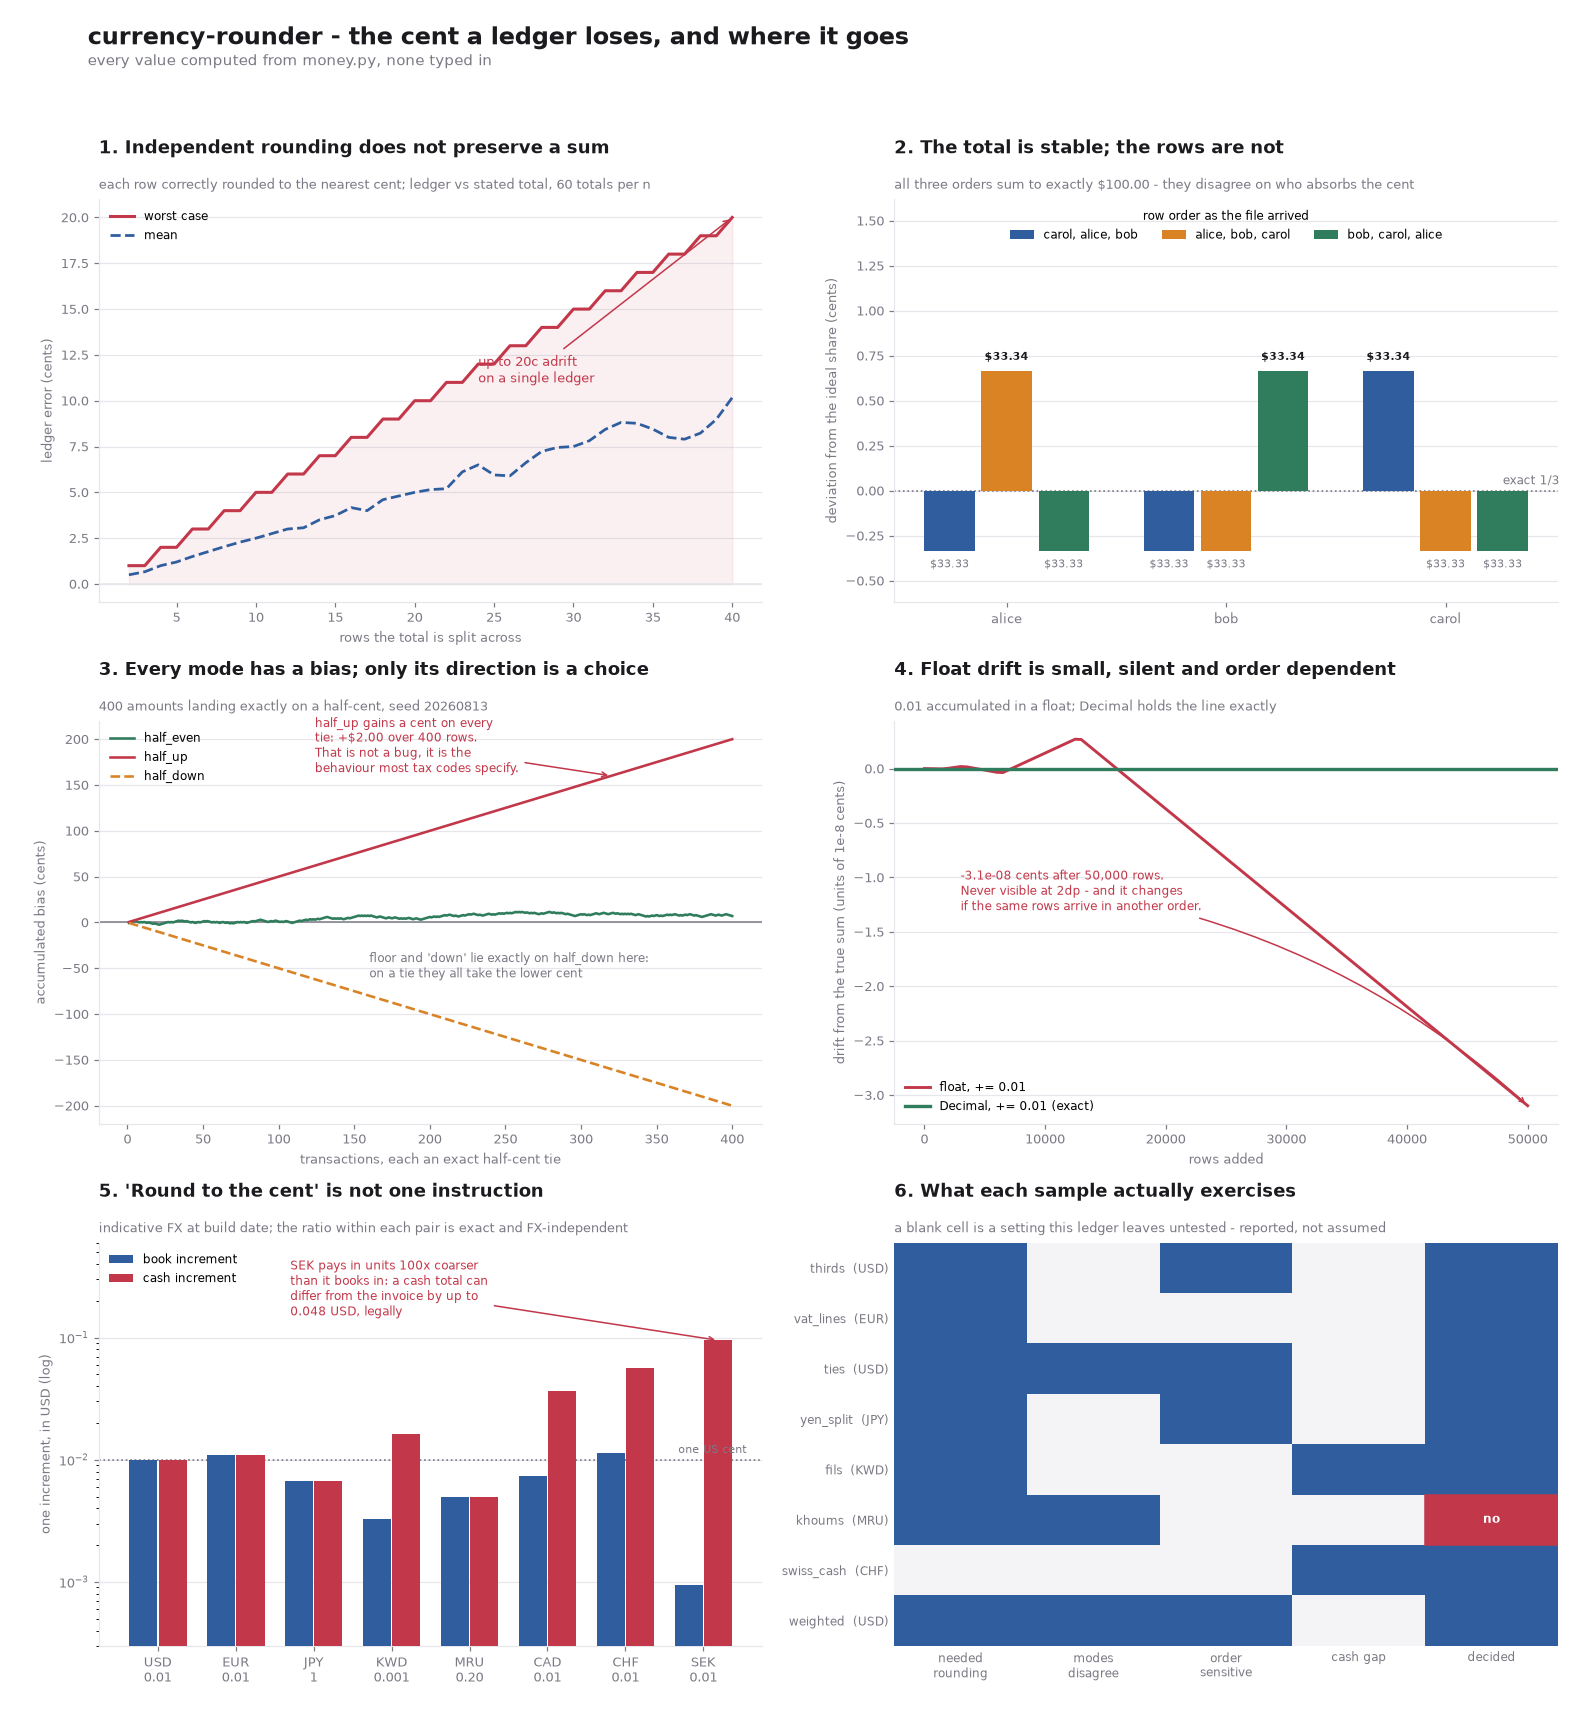

In [16]:
import make_chart
import matplotlib.pyplot as plt
from IPython.display import Image, display

fig, axes = plt.subplots(3, 2, figsize=(14.5, 15.6))
fig.patch.set_facecolor("white")
make_chart.p1_shortfall(axes[0][0])
make_chart.p2_who_pays(axes[0][1])
make_chart.p3_mode_bias(axes[1][0])
make_chart.p4_float_drift(axes[1][1])
make_chart.p5_minor_units(axes[2][0])
make_chart.p6_verdicts(axes[2][1])
fig.suptitle("currency-rounder - the cent a ledger loses, and where it goes",
             fontsize=16, fontweight="bold", color=make_chart.INK, x=0.055, ha="left", y=0.985)
fig.text(0.055, 0.962, "every value computed from money.py, none typed in",
         fontsize=9.6, color=make_chart.MUTED, ha="left")
fig.tight_layout(rect=[0.012, 0.008, 0.988, 0.952])
fig.savefig("rounding_audit_nb.png", dpi=110, facecolor="white")
plt.close(fig)
display(Image("rounding_audit_nb.png"))

## Summary

| mechanism | sample | what it costs | raises? |
|---|---|---|---|
| rows rounded independently | `thirds` | ledger $0.01 short | no |
| penny placed by row position | `weighted` | $0.01 variance from a sort order | no |
| `half_even` where law says `half_up` | `ties` | four rows, $0.02 apart | no |
| float literal rounded | `2.675` | rounds down off a non-tie | no |
| float accumulation | `0.01` x 10,000 | sub-cent drift, order dependent | no |
| line tax vs invoice tax | `vat_lines` | the return disagrees with the invoice | no |
| rounding twice | `2.4449` | `2.45` instead of `2.44` | no |
| discount before vs after tax | `19.99` | $0.01 per order | no |
| `round(x, 2)` on a 3-decimal currency | `fils` | amount becomes unstorable | no |
| exponent read as the subdivision | `khoums` | an unpayable amount accepted | no |
| book total compared against cash | `swiss_cash` | CHF 0.02 permanent difference | no |

The design rule underneath all of it: **a function that returns one number cannot report
what it had to assume to get there.** So `classify_delimiter`-style enumeration applies to
money too - return the verdict, the residual, the rows that absorbed it, and the settings
this ledger never exercised.

## Try your own

In [17]:
# Paste your own rows below and re-run this cell.
#
# my_rows = [("north", D("1250.005")), ("south", D("1250.005")), ("east", D("2500.01"))]
# my_total = D("5000.02")
# my_currency = m.currency("USD")          # try "JPY", "KWD", "CHF", "MRU"
#
# rec = m.reconcile([a for _, a in my_rows], my_currency, my_total, "half_up",
#                   [l for l, _ in my_rows])
# print(rec.verdict, "-", rec.reason)
# if rec.allocation:
#     for lab, part in rec.allocation.by_label().items():
#         print(f"  {lab:10} {part}")
#     print("  sum:", sum(rec.allocation.parts))
# for note in rec.untested:
#     print("  untested:", note)

# Or run the full evidence script, which prints every table in the README:
# import evidence; evidence.main()

---

**Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) - Day 143, Data Engineering Pro.**

- [`README.md`](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/currency-rounder) - the write-up, with every table above
- `python3 test_money.py` - the suite (structural assertions only; it never asserts what a
  given CPython's `round()` returns)
- `python3 evidence.py` - reproduces every number in the README
- `streamlit run app.py` - the UI, verdict first and the table last